# 02 — Data loading and validation

I load one selected Allen experiment and validate the core objects before preprocessing: ΔF/F traces, fluorescence timestamps, and natural movie stimulus tables.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


In [2]:
import pandas as pd
from v1_manifold.data_access import get_boc, get_experiment_data, extract_dff_and_metadata, get_stimulus_table
from v1_manifold.schema import validate_dff_traces, validate_stimulus_table

if not paths.external_metadata.exists():
    raise FileNotFoundError("I need to run notebook 01 first so the experiment catalog exists.")
experiments = pd.read_csv(paths.external_metadata)
if experiments.empty:
    raise RuntimeError("The experiment catalog is empty. I need to relax the filters in configs/default.yaml.")

experiment_id = int(experiments.iloc[0]["id"])
boc = get_boc(paths.allen_manifest)
data_set = get_experiment_data(boc, experiment_id)
cell_meta, dff, timestamps = extract_dff_and_metadata(data_set)
stim = get_stimulus_table(data_set, cfg["preprocessing"]["stimulus_name"])

trace_summary = validate_dff_traces(dff)
stim_summary = validate_stimulus_table(stim)
trace_summary, stim_summary, cell_meta.head(), stim.head()

c:\Users\Peter\.neuro\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


({'n_cells': 164, 'n_timepoints': 105959},
 {'n_presentations': 9000},
    cell_specimen_id
 0         517407830
 1         517407895
 2         517407877
 3         517408439
 4         587435695,
    frame  start    end  repeat
 0      0  31510  31511       0
 1      1  31511  31512       0
 2      2  31512  31513       0
 3      3  31513  31514       0
 4      4  31514  31515       0)

In [3]:
validation = pd.DataFrame([
    {"object": "dff_traces", **trace_summary},
    {"object": "stimulus_table", **stim_summary},
    {"object": "cell_metadata", "n_cells_metadata": len(cell_meta)},
])
save_table(validation, paths.tables_dir / f"02_validation_experiment_{experiment_id}.csv")
validation

,object,n_cells,n_timepoints,n_presentations,n_cells_metadata
0,dff_traces,164.0,105959.0,NaN,NaN
1,stimulus_table,NaN,NaN,9000.0,NaN
2,cell_metadata,NaN,NaN,NaN,164.0


Experiments to plot: [500855614, 500964514, 501271265]
Loading experiment 500855614...


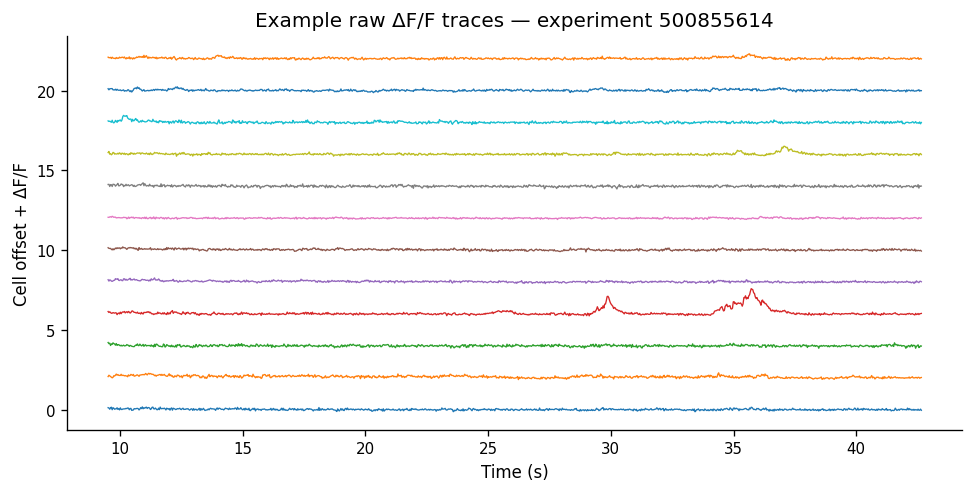

Loading experiment 500964514...


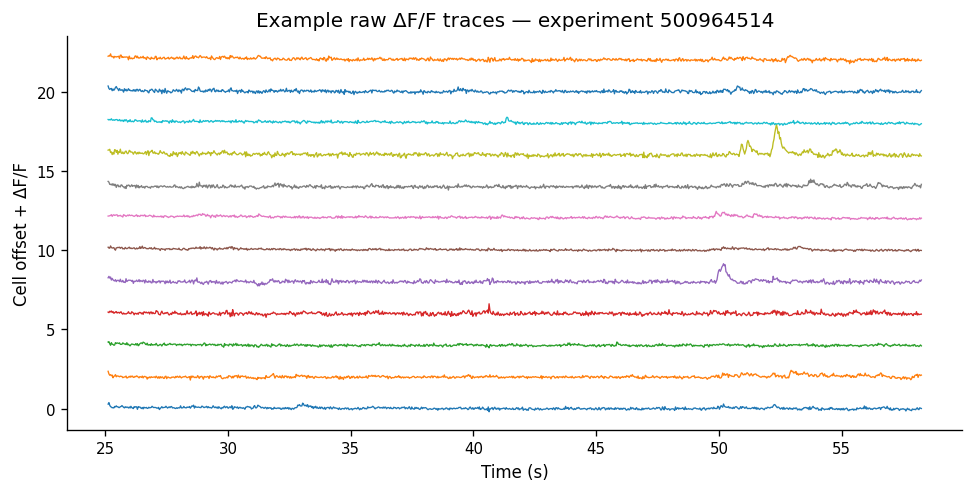

Loading experiment 501271265...


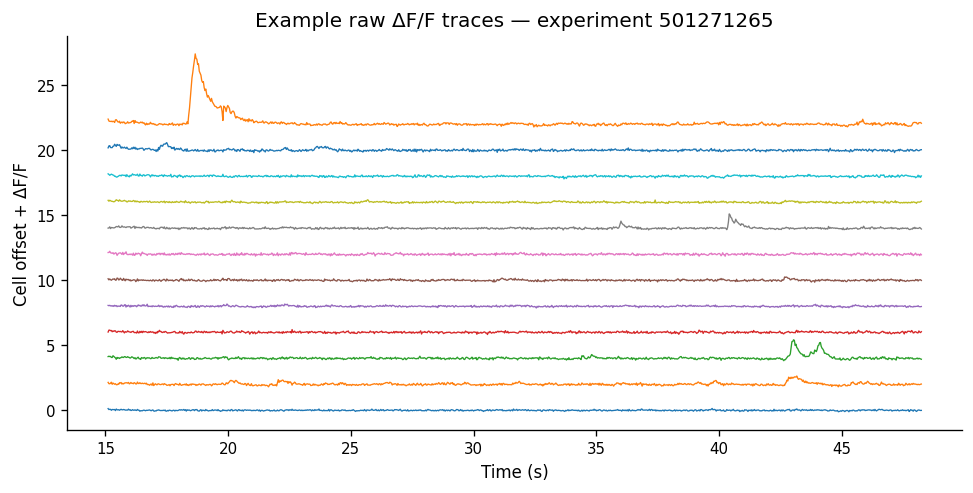

In [6]:
# Use downloaded IDs if available; otherwise fall back to selected experiment IDs.
if "downloaded" in globals() and len(downloaded) > 0:
    experiment_ids = downloaded
else:
    experiment_ids = experiments["id"].tolist()

print("Experiments to plot:", experiment_ids)

for experiment_id in experiment_ids:
    print(f"Loading experiment {experiment_id}...")

    data_set = boc.get_ophys_experiment_data(experiment_id)

    # AllenSDK returns: timestamps, dff_traces
    timestamps, dff = data_set.get_dff_traces()

    n_show = min(12, dff.shape[0])

    fig, ax = plt.subplots(figsize=(8, 4))

    for i in range(n_show):
        ax.plot(
            timestamps[:1000],
            dff[i, :1000] + i * 2.0,
            linewidth=0.8,
        )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Cell offset + ΔF/F")
    ax.set_title(f"Example raw ΔF/F traces — experiment {experiment_id}")

    save_figure(
        fig,
        paths.figures_dir / f"01_example_raw_dff_traces_experiment_{experiment_id}.png",
    )

    plt.show()